# 2.1.1 从逐步变化到递推规则

## 学习目标与先修知识

能把逐步变化写成含下标的递推关系（recurrence relation），区分初值（initial condition）、每步倍数和固定点（fixed point）；用有限求和核对累计变化。

先修：第 1 篇的收支（mass balance）、初值与模型（model）比较；Python 的列表和循环。 [复习上一节](../../01-看见系统/04-模型假设与计算实验/02-设计可以区分解释的实验.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

人工培养计数从 10 个开始，每个观察周期保留 80%。另一个物质池每周期保留一半，再补入 1 U。两条规则都在“变少”，为什么一条趋近零，另一条趋近非零水平？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()

## 初步实验

先按给定条件计算，再用后面的推导解释结果。

In [2]:
cells = [10.0]
pool = [0.0]
for _ in range(4):
    cells.append(0.8 * cells[-1])
    pool.append(0.5 * pool[-1] + 1)
display(Markdown(show_table(['周期 n','计数 / 个','池内量 / U'], zip(range(5),cells,pool))))

| 周期 n | 计数 / 个 | 池内量 / U |
| --- | --- | --- |
| 0 | 10 | 0 |
| 1 | 8 | 1 |
| 2 | 6.4 | 1.5 |
| 3 | 5.12 | 1.75 |
| 4 | 4.096 | 1.875 |

## 模型假设

一个周期固定为 1 T。计数是允许实数的平均计数，不模拟单个细胞；不考虑密度限制。物质池先保留再补入，顺序是模型的一部分。本节限定 $A_0\ge0$、$q\ge0$、$b\ge0$，从而每次更新的平均计数或所追踪物质总量（tracked amount）均非负。

| 量 | 含义 | 单位 |
|---|---|---|
| $A_n$、$A_0$ | 第 n 次更新后的总量、初始总量 | U |
| $q$ | 每周期保留或增长倍数 | 1 |
| $b$ | 每周期末额外补入量 | U |
| $n$ | 完成更新的次数，不是连续时间 | 次 |

计数采用初值 10、每步倍数 $q=0.8$；物质池采用初值 0 U、每步倍数 $q=0.5$ 与补入量 $b=1$ U。

## 数学解释与推导

下标 $n$ 是位置标签：$A_0$ 表示起点，$A_1$ 是一次更新后。把规则写成
$$A_{n+1}=qA_n+b.$$
这是一条差分方程（difference equation）；差分就是相邻状态（state）的差 $A_{n+1}-A_n=(q-1)A_n+b$。若 $b=0$，反复代入得到 $A_n=q^n A_0$。对本节限定的非负倍数 $q$，当 $b=0$ 且 $A_0>0$ 时：$0\le q<1$ 表示衰减（$q=0$ 时一步归零），$q=1$ 保持不变，$q>1$ 表示增长，不涉及连续时间速率。若 $A_0=0$ 且 $b=0$，状态始终为零。有补入时不能直接用这一分类判断 $A_n$ 的变化。

若以后允许一般实数倍数，零点附近的幅度衰减要求 $|q|<1$；负倍数会使符号交替。例如 $q=-2$ 虽小于 1，但 $|A_n|=2^n|A_0|$ 增长，不属于本节的非负总量模型。

将每段变化相加，中间量相消：
$$A_n-A_0=\sum_{j=0}^{n-1}(A_{j+1}-A_j).$$
$\sum$ 表示按给定下标逐项相加；上式有 n 项，与 n 次更新一致。代入带补入的规则，则
$$A_n=q^n A_0+b(1+q+\cdots+q^{n-1}).$$
令括号为 S，$S-qS=1-q^n$，故当 $q\ne1$ 时 $S=(1-q^n)/(1-q)$；当 $q=1$ 时直接有 $S=n$，不能除以零。

固定点是代入一次仍不变的量：$A^*=qA^*+b$，所以 $q\ne1$ 时 $A^*=b/(1-q)$。这只给出不变位置。进一步相减得到 $A_{n+1}-A^*=q(A_n-A^*)$；在本例 $0<q<1$ 时偏离逐步缩小。固定点不意味着所有起点一步到达。

每步倍数依赖“一步”的定义。把记录间隔减半不能还用原 q；若额外假设两个相同半步应合成一个整步，才有 $q_{1/2}^2=q$。例如保留 80% 的整步对应半步保留 $\sqrt{0.8}$，而非 0.8。

## 核心实现

函数只接收本节定义的量；核心计算步骤如下。

In [3]:
def growth(initial, factor, steps):
    values = [initial]
    for _ in range(steps):
        values.append(factor * values[-1])
    return values

## 对照实验

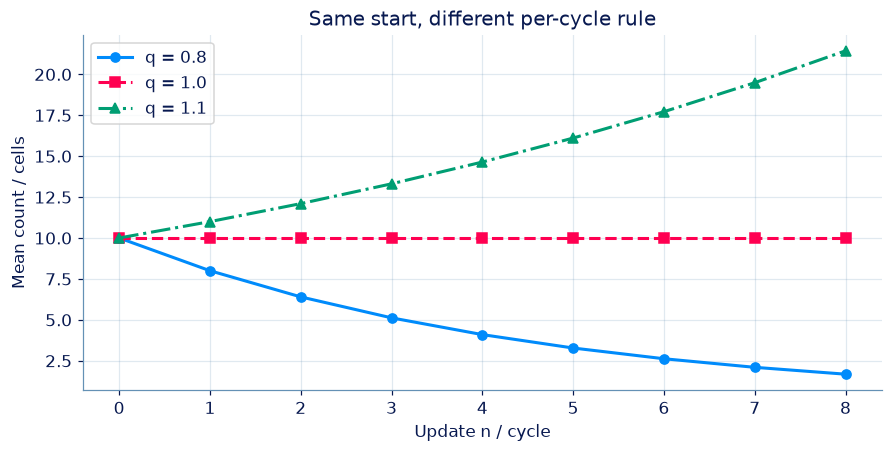

| 周期 | 带补入的闭式结果 / U |
| --- | --- |
| 0 | 0 |
| 1 | 1 |
| 2 | 1.5 |
| 3 | 1.75 |
| 4 | 1.875 |

In [4]:
fig, ax = plt.subplots()
for factor, style in [(0.8,'o-'),(1.0,'s--'),(1.1,'^-.')]:
    values = growth(10, factor, 8)
    ax.plot(range(9), values, style, label=f'q = {factor}')
ax.set(xlabel='Update n / cycle', ylabel='Mean count / cells', title='Same start, different per-cycle rule')
ax.legend(); plt.show()
fixed = [2 + (0 - 2) * 0.5**n for n in range(5)]
display(Markdown(show_table(['周期','带补入的闭式结果 / U'], enumerate(fixed))))

## 结果解释

三条计数曲线共享起点与周期，只有倍数不同。带补入的池内量从 0、1、1.5、1.75…靠近 2 U，计数衰减却靠近零。连点线只帮助读图；这里的规则定义在离散周期上，并未规定两点之间怎样变化。

### 独立核对

用幂函数闭式核对循环结果，再把各段变化相加，检查它是否等于末值减初值。

In [5]:
np.testing.assert_allclose(growth(10,.8,4), [10*.8**n for n in range(5)])
np.testing.assert_allclose(pool, fixed)
assert math.isclose(sum(pool[i+1]-pool[i] for i in range(4)), pool[-1]-pool[0])
assert growth(7,1,0) == [7]
assert math.isclose(math.sqrt(.8)**2,.8)
print('闭式、累计变化、零次更新与半步组合均一致。')

闭式、累计变化、零次更新与半步组合均一致。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/02-01-用递推描述增长与清除/explore/)：先预测改变一个条件后的结果，再回到这里对照推导与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：每步比例属于哪一个时钟

一次人工细胞计数模型（model）规定每隔 1 T 更新一次，每次保留原计数的 80%，不含新增。若把记录时刻改成每 0.5 T 一次，哪项说法成立？

- **A.** 仍把每半个 T 的保留比例设为 0.8，必定是同一个模型。
- **B.** 若额外假设两个半步采用相同比例且乘积为 0.8，半步比例为 sqrt(0.8)。
- **C.** 每步 0.8 的单位是 1/T。
- **D.** 只需改横轴标签，任何更新次数都不影响终点。

[作答：每步比例属于哪一个时钟](http://127.0.0.1:8000/chapters/02-01-%E7%94%A8%E9%80%92%E6%8E%A8%E6%8F%8F%E8%BF%B0%E5%A2%9E%E9%95%BF%E4%B8%8E%E6%B8%85%E9%99%A4/practice/?question=p02-step-factor)

### 第 2 题 · Python 计算题：逐步计算保留或增长

用相同的每步倍数预测理想细胞计数。计数可为实数，代表模型（model）中的平均数量。返回起点和每次更新后的全部值；不把模型值取整。

**函数与代码模板**

```python
def solve(
    initial: float,
    factor: float,
    steps: int,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `float` | 初始计数。 | 个 |
| `factor` | `float` | 每次更新乘上的倍数。 | 1 |
| `steps` | `int` | 更新次数。 | 步 |

**返回值**

直接返回 values（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 含起点，长度为 steps + 1。 | 个 |

**计算规则**

values[0] = initial；values[n+1] = factor × values[n]。

**约束与边界**

- 所有数值有限；无需修改输入（input）。
- 0 ≤ initial ≤ 100；0 ≤ factor ≤ 1.2；0 ≤ steps ≤ 30。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 初始计数。 | 10 | 个 |
| factor | 每次更新乘上的倍数。 | 0.8 | 1 |
| steps | 更新次数。 | 3 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = 10
factor = 0.8
steps = 3

result = solve(initial, factor, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| values | 含起点，长度为 steps + 1。 | [10, 8.0, 6.4, 5.120000000000001] | 个 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [10, 8.0, 6.4, 5.120000000000001]
```

**样例解释**

10 个依次乘 0.8，得到 [10, 8, 6.4, 5.12]。列表第一个数是起点，不是第一步结果。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：逐步计算保留或增长](http://127.0.0.1:8000/chapters/02-01-%E7%94%A8%E9%80%92%E6%8E%A8%E6%8F%8F%E8%BF%B0%E5%A2%9E%E9%95%BF%E4%B8%8E%E6%B8%85%E9%99%A4/practice/?question=p02-growth)

### 第 3 题 · 单项选择题：累计量为什么包含 n 项

规则为 A[n+1] = A[n] + b[n]，从 A[0] 更新到 A[3]。哪一个表达式与三次更新一致？

- **A.** A[3] = b[3]。
- **B.** A[3] = A[0] + b[1] + b[2] + b[3]。
- **C.** A[3] = A[0] + b[0] + b[1] + b[2]。
- **D.** A[3] = 3 × A[0] + b[0]。

[作答：累计量为什么包含 n 项](http://127.0.0.1:8000/chapters/02-01-%E7%94%A8%E9%80%92%E6%8E%A8%E6%8F%8F%E8%BF%B0%E5%A2%9E%E9%95%BF%E4%B8%8E%E6%B8%85%E9%99%A4/practice/?question=p02-sum-index)

### 第 4 题 · 多项选择题：不变状态与起点

人工离散模型（model） A[n+1] = 0.5 A[n] + 1，所追踪物质总量（tracked amount）单位 U。以下哪些成立？

- **A.** A=2 U 是固定点（fixed point）。
- **B.** 只要固定点为 2 U，任何初值（initial condition）第一步都会变成 2 U。
- **C.** 从 0 U 开始，前三次更新是 1、1.5、1.75 U。
- **D.** 每步距 2 U 的偏差都乘 0.5。

[作答：不变状态与起点](http://127.0.0.1:8000/chapters/02-01-%E7%94%A8%E9%80%92%E6%8E%A8%E6%8F%8F%E8%BF%B0%E5%A2%9E%E9%95%BF%E4%B8%8E%E6%B8%85%E9%99%A4/practice/?question=p02-fixed-point)

**进一步阅读**

[MIT 微积分课程](https://ocw.mit.edu/courses/18-01sc-single-variable-calculus-fall-2010/)：指数、求和与极限的后续数学背景。